In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.drop(['PassengerId','Name', 'Ticket'], axis = 1, inplace= True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [4]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [5]:
def chk_types(data):
    dtypes = df.dtypes
    n_uniq = df.nunique()
    
    return pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

In [6]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T



In [7]:
chk_types_table(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Unique,2,3,2,88,7,7,248,147,3


In [8]:
cols = ['Pclass',
        'Survived',
        'Sex',
        'SibSp',
        'Parch',
        'Embarked']
df[cols] = df[cols].astype('category')

In [9]:
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,str,category
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [10]:
df.shape[0]

891

In [11]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio %,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [12]:
median_1 = df['Age'].median()
df['Age'] = df['Age'].fillna(median_1, inplace=True)


C:\Users\BEBO\AppData\Local\Temp\ipykernel_16008\1822207619.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(median_1, inplace=True)


In [13]:
df.dropna(subset=['Embarked'], inplace= True)

In [14]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,687.00000,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.27784,0.0


In [15]:
num_cols = ["Age","Fare"]

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

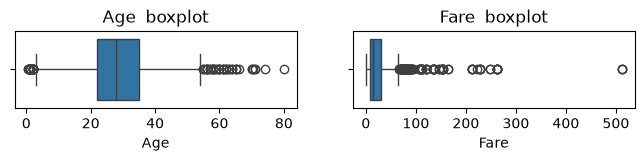

In [17]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col}  boxplot")
plt.show()

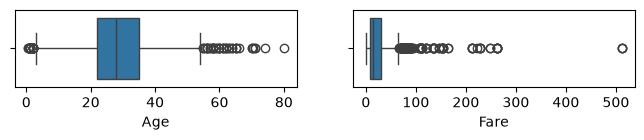

In [18]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient = "h")
    
    

In [19]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(.75)
    # print(Q1,Q3)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5* IQR
    upper_fence = Q3 + 1.5* IQR
    print(lower_fence)
    lower_outliers = df[ df[col] < lower_fence][col].values 
    upper_outliers = df[ df[col] > upper_fence][col].values 
    print(lower_outliers)
    
    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)


2.5
[2.   2.   0.83 2.   1.   1.   1.   2.   2.   0.92 2.   1.   1.   0.75
 2.   2.   2.   0.75 0.67 1.   0.42 2.   1.   0.83]
-26.7605
[]


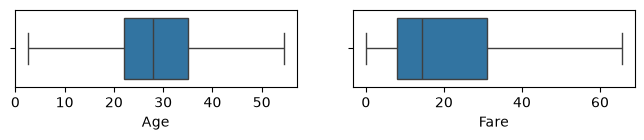

In [20]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient = "h")
    
    

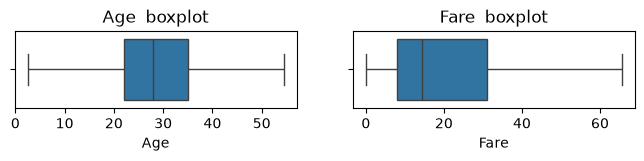

In [21]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col}  boxplot")
plt.show()

In [22]:
df.duplicated().sum()

np.int64(116)

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
def remove_duplicated(df,subset_col= None , keep_stratgy = "first"):
    return (df.drop_duplicates(subset = subset_col,keep= keep_stratgy).reset_index(drop = True))

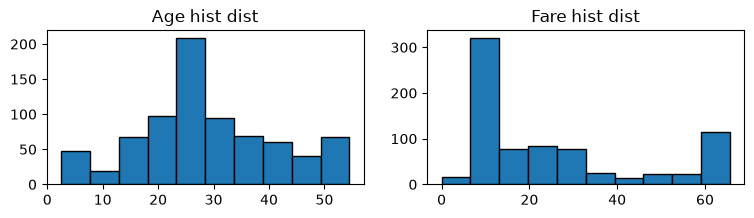

In [25]:
plt.figure(figsize=(9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.hist(df[col],edgecolor="black")
    plt.title(f"{col} hist dist")
    

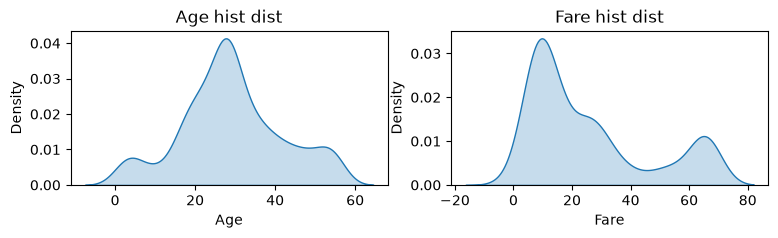

In [26]:
plt.figure(figsize=(9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.kdeplot(data=df[col],fill=True)
    plt.title(f"{col} hist dist")
    

In [27]:
cat_col = df.select_dtypes("category")
cat_col

,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0,3,male,1,0,S
1,1,1,female,1,0,C
2,1,3,female,0,0,S
3,1,1,female,1,0,S
4,0,3,male,0,0,S
...,...,...,...,...,...,...
885,0,3,female,0,5,Q
887,1,1,female,0,0,S
888,0,3,female,1,2,S
889,1,1,male,0,0,C


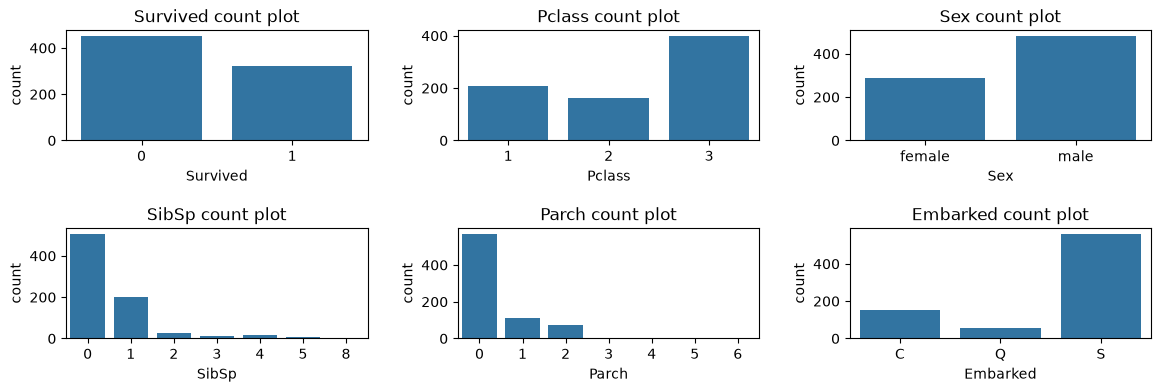

In [28]:
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_col):
    plt.subplot(2,3,i+1)
    sns.countplot(x= col , data= df)
    plt.title(f"{col} count plot")
plt.subplots_adjust(hspace=0.8,wspace=0.3)
plt.show()
    

In [54]:
unique = df['Survived'].value_counts()
print(unique)
count = unique.values
print(count)
categories = unique.index
print(categories)

Survived
0    453
1    320
Name: count, dtype: int64
[453 320]
CategoricalIndex([0, 1], categories=[0, 1], ordered=False, dtype='category', name='Survived')


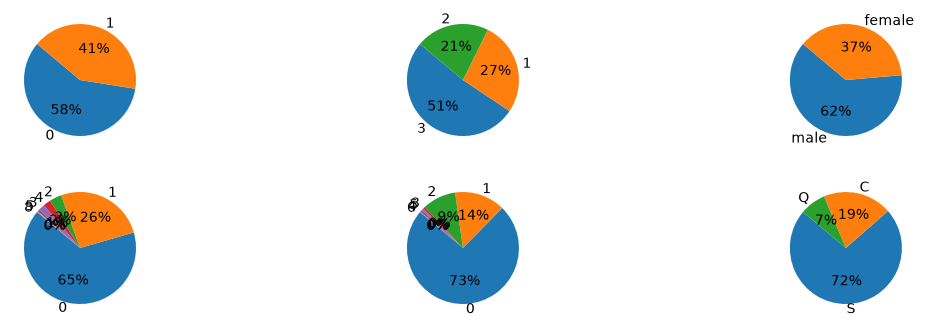

In [30]:
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_col):
    plt.subplot(2,3,i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count,labels=categories,startangle=140,autopct='%1.1d%%')

In [31]:
import plotly.express as px


In [32]:
fig = px.pie(df,names="Survived",labels=unique)
fig.show()

In [33]:
fig = px.pie(df,names="Survived",
            color_discrete_sequence=px.colors.qualitative.Pastel,)
fig.show()

In [34]:

fig = px.pie(df,names="Survived",
            color_discrete_sequence=px.colors.qualitative.Pastel,
            hole= 0.6)
fig.show()

# (1)data distribution graph

### 1- numerical distribution (Histgram) -> plt

In [35]:
num_cols

['Age', 'Fare']

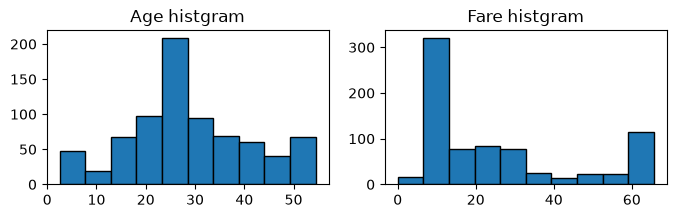

In [45]:
plt.figure(figsize=(8,2))
for i , col in enumerate(num_cols):
	plt.subplot(1,2,i+1)
	plt.hist(df[col], edgecolor='black')
	plt.title(f"{col} histgram")

plt.show()
    
    

### 2- numerical distribution (KDE plot) -> sns

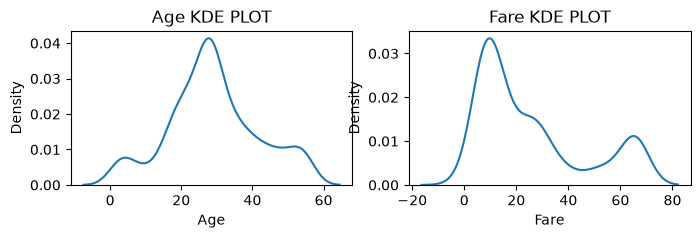

In [49]:
plt.figure(figsize=(8,2))
for i , col in enumerate(num_cols):
	plt.subplot(1, 2, i+1)
	sns.kdeplot(df[col])
	plt.title(f"{col} KDE PLOT")

plt.show()


### 1- categorical data distribution (countplot) -> sns

In [ ]:
cat_col

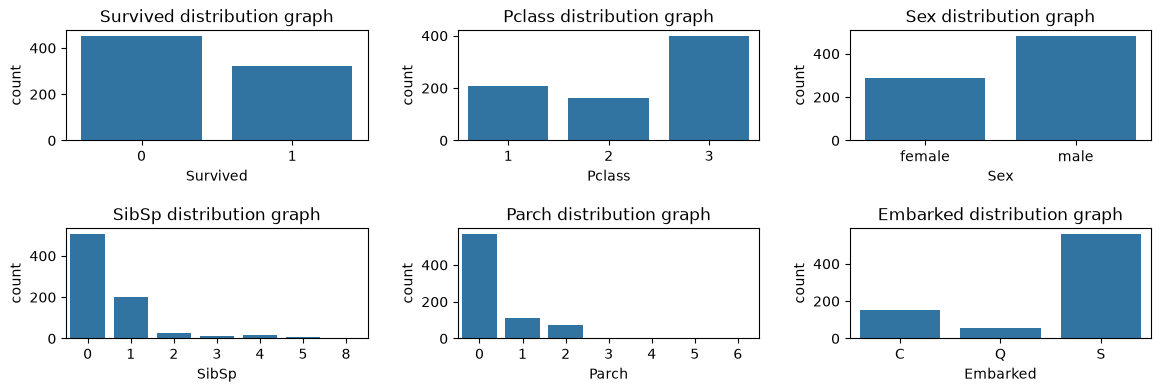

In [53]:
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_col):
	plt.subplot(2, 3, i+1)
	sns.countplot(x= col , data= df)
	plt.title(f"{col} distribution graph")
plt.subplots_adjust(hspace=0.8, wspace=0.3)
plt.show()


### 2- categorical data distribution (pieplot) -> plt

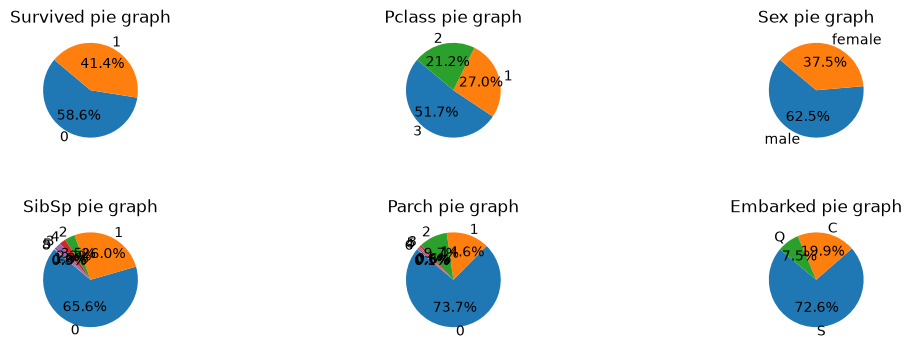

In [ ]:
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_col):
	plt.subplot(2, 3, i+1)
	unique = df[col].value_counts()
	count = unique.values
	categories = unique.index
	plt.pie(count,labels=categories,startangle= 140,autopct='%1.1f%%')
	plt.title(f"{col} pie graph")
 
plt.subplots_adjust(hspace=0.6, wspace=0.1)
plt.show()


# (2) outliers - graph

### 1- box plot -> sns


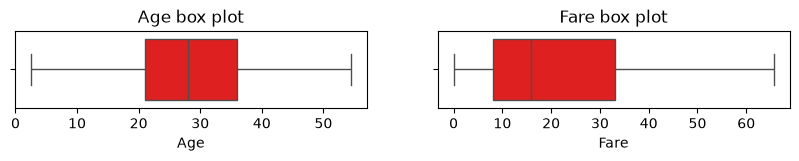

In [64]:
plt.figure(figsize=(10,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient='h',color="red")
    plt.title(f"{col} box plot")
    
plt.show()    
    

# (3) relations - graph

### (1) relation --> numerical : numerical

#### 1- scatter  -> plt

<function matplotlib.pyplot.show(close=None, block=None)>

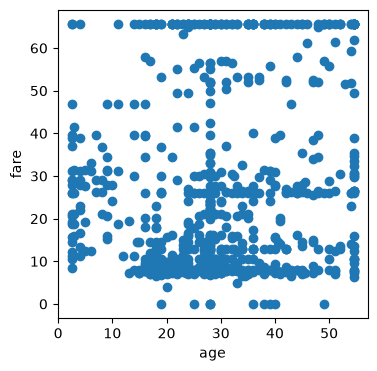

In [66]:
plt.figure(figsize=(4,4))
plt.scatter(df['Age'],df['Fare'])
plt.xlabel("age")
plt.ylabel("fare")
plt.show

#### 2- pair plot  -> sns

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 400x400 with 0 Axes>

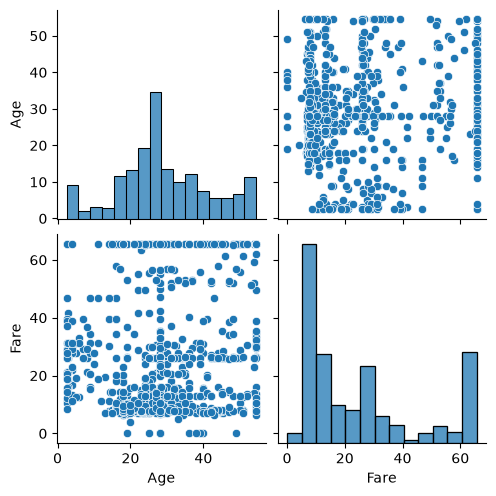

In [67]:
plt.figure(figsize=(4,4))
sns.pairplot(df)
plt.xlabel("age")
plt.ylabel("fare")
plt.show

#### 3- line plot  -> plt

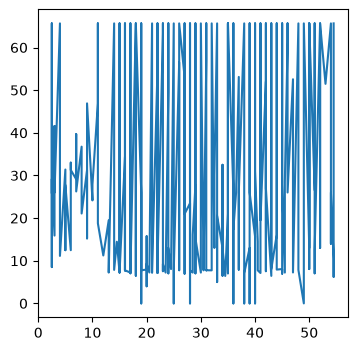

In [68]:
sorted_df = df.sort_values(by = "Age")
plt.figure(figsize=(4,4))
plt.plot(sorted_df['Age'],sorted_df['Fare'])
plt.show()

#### 4- heatmap  -> sns

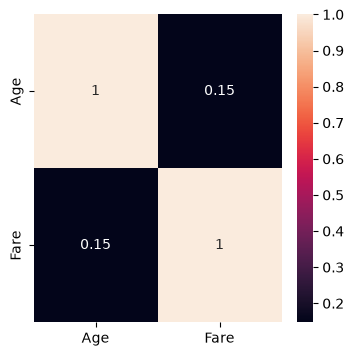

In [70]:
corr = df.corr(numeric_only= True)
plt.figure(figsize=(4,4))
sns.heatmap(corr,annot= True)
plt.show()

### (2) relation --> numerical : categorical

### 1- bar plot -> sns

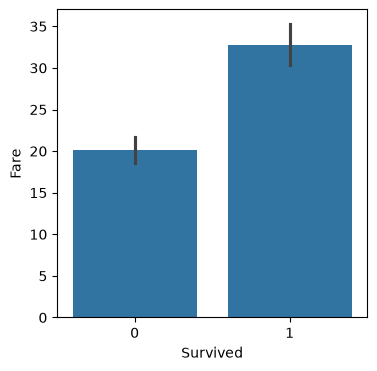

In [74]:
plt.figure(figsize=(4,4))
sns.barplot(x= "Survived", y="Fare" , data= df)
plt.show()

### (3) relation --> categorical : categorical

### 1-heatmap -> sns

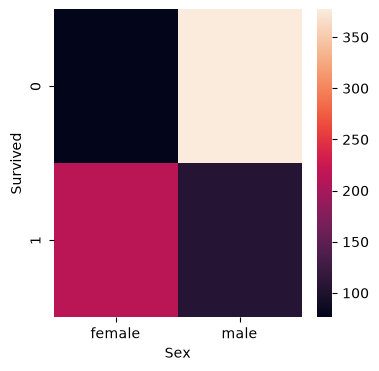

In [90]:
plt.figure(figsize=(4,4))
agg = df.pivot_table(index="Survived", columns="Sex", values="Age", aggfunc=len)
sns.heatmap(agg)
plt.show()

<Axes: xlabel='Sex', ylabel='Survived'>

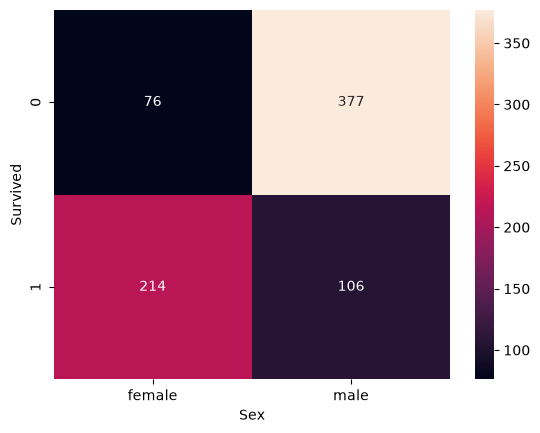

In [88]:
cross = pd.crosstab(df["Survived"], df["Sex"])
cross
sns.heatmap(
    cross,
    annot=True,
    fmt="d"
)